In [2]:
import dotenv
%load_ext dotenv
%dotenv

import os
import platform

import json
import random
import pickle

import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_flags

from envs.env_utils import make_env_and_datasets
from utils.datasets import Dataset
from utils.log_utils import get_exp_name
from utils.networks import LatentLyapunovFunction


seed=0

# model_path, hidden_dims = "exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250912_222113", [512,512,512]
# model_path, hidden_dims = "exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250912_224342", [512,512,512]
# model_path, hidden_dims="exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250912_180927", [256,256,256]
model_path, hidden_dims="exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250912_230922", [512, 512, 512]
model_step=1000000
env_name="antmaze-large-navigate-singletask-task1-v0"

## MODEL PARAMETERS
latent_dim=16
layer_norm=False

p_aug=None
frame_stack=None

def load_lyapunov_network(model_path, model_step, lyapunov_fn, state_dim, action_dim):
    """Load the saved Lyapunov network parameters."""
    # Load parameters
    params_path = os.path.join(model_path, f'lyapunov_params_step_{model_step}.npz')
    tree_path = os.path.join(model_path, f'lyapunov_tree_step_{model_step}.pkl')
    
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"Parameters file not found: {params_path}")
    if not os.path.exists(tree_path):
        raise FileNotFoundError(f"Tree structure file not found: {tree_path}")
    
    # Load tree definition
    with open(tree_path, 'rb') as f:
        tree_def = pickle.load(f)
    
    # Load flattened parameters
    params_data = np.load(params_path)
    flat_params = [params_data[f'arr_{i}'] for i in range(len(params_data.files))]
    
    # Reconstruct parameter tree
    params = jax.tree_util.tree_unflatten(tree_def, flat_params)
    
    print(f"Loaded Lyapunov network from {model_path} at step {model_step}")
    return params


def lyapunov_value(params, apply_fn, states, actions):
    """
    Get the actual Lyapunov value: -V(s,a) (negated for proper interpretation)
    Use this for evaluation and plotting where lower values should indicate safer actions
    """
    return -apply_fn(params, states, actions)


print("=" * 60)
print("LYAPUNOV FUNCTION ANALYSIS")
print("=" * 60)

# Validate required arguments
if env_name is None:
    raise ValueError("Must specify --env_name to load saved model")
if model_path is None:
    raise ValueError("Must specify --model_path to load saved model")
if model_step is None:
    raise ValueError("Must specify --model_step to load saved model")

# Make environment and datasets
env, eval_env, train_dataset, val_dataset = make_env_and_datasets(
    env_name, frame_stack=frame_stack
)

# Initialize random seeds
random.seed(seed)
np.random.seed(seed)

# Set up dataset
train_dataset = Dataset.create(**train_dataset)
train_dataset.p_aug = p_aug
train_dataset.frame_stack = frame_stack

# Get state and action dimensions from environment
example_batch = train_dataset.sample(1)
state_dim = example_batch['observations'].shape[-1]
action_dim = example_batch['actions'].shape[-1]

print(f"Environment: {env_name}")
print(f"State dimension: {state_dim}")
print(f"Action dimension: {action_dim}")
print(f"Dataset size: {train_dataset.size}")

# Create Lyapunov network
hidden_dims = [int(x) for x in hidden_dims]
lyapunov_fn = LatentLyapunovFunction(
    hidden_dim=hidden_dims,
    state_dim=state_dim,
    action_dim=action_dim,
    latent_dim=latent_dim,
    layer_norm=layer_norm
)

# Load trained parameters
params = load_lyapunov_network(model_path, model_step, lyapunov_fn, state_dim, action_dim)
apply_fn = lyapunov_fn.apply

print(f"Network architecture: {state_dim + action_dim} -> {latent_dim} -> {hidden_dims} -> 1")
print("Model loaded successfully!")
print("Ready for analysis...")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:14: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


LYAPUNOV FUNCTION ANALYSIS
Environment: antmaze-large-navigate-singletask-task1-v0
State dimension: 29
Action dimension: 8
Dataset size: 1000000
Loaded Lyapunov network from exp/lyapunov/LyapunovTraining/lyapunov_antmaze-large-navigate-singletask-task1-v0_sd000_20250912_230922 at step 1000000
Network architecture: 37 -> 16 -> [512, 512, 512] -> 1
Model loaded successfully!
Ready for analysis...


In [3]:
# Load corresponding model for critic analysis
model_path="/mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250907_031541_utd-ratio1"
restore_epoch=1000000
from agents import agents
from utils.flax_utils import restore_agent
from agents.fbrac import get_config as get_fbrac_config
fbrac_config = get_fbrac_config()

fbrac_agent_class = agents[fbrac_config['agent_name']]
fbrac_agent_jcb = fbrac_agent_class.create(
    seed,
    example_batch['observations'],
    example_batch['actions'],
    fbrac_config,
)

# Restore trained models
if model_path and restore_epoch:
    fbrac_agent_jcb = restore_agent(fbrac_agent_jcb, model_path, restore_epoch)
    print(f"FBRAC agent restored from {model_path} at epoch {restore_epoch}")

print("Models loaded successfully!")


Restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250907_031541_utd-ratio1/params_1000000.pkl
FBRAC agent restored from /mnt/nas/jaehyeok/fql/exp/fql/Debug/fbrac_antmaze-large-navigate-singletask-task1-v0_sd000_20250907_031541_utd-ratio1 at epoch 1000000
Models loaded successfully!


In [14]:
def sample_state(x, y, batch):
    states = batch['observations']
    actions = batch['actions']

    # Get the states near the given x, y
    idx = (states[:, 0] >= x - 0.1) & (states[:, 0] <= x + 0.1) & (states[:, 1] >= y - 0.1) & (states[:, 1] <= y + 0.1)
    states_near = states[idx]
    dataset_actions = actions[idx]
    return states_near, dataset_actions

def compute_sa_values(critic_fn, states, actions, q_agg='min', batch_size=256):
    qs = []
    for i in range(0, len(states), batch_size):
        batch_end = min(i + batch_size, len(states))
        batch_states = states[i:batch_end]
        batch_actions = actions[i:batch_end]
        current_qs = critic_fn(batch_states, batch_actions)
        if q_agg == 'min':
            current_qs = current_qs.min(axis=0)
        else:
            current_qs = current_qs.mean(axis=0)
        qs.append(current_qs)
    return np.concatenate(qs, axis=0)


search_space = train_dataset.sample(1000000)

# Critic function def
critic_fn = fbrac_agent_jcb.network.select('critic')

In [38]:
x, y = 27, 17
target_states, dataset_actions = sample_state(x, y, search_space)
target_idx = np.random.choice(np.arange(target_states.shape[0]))

target_state = target_states[target_idx]
target_action = dataset_actions[target_idx]

num_similar=5
# find the states with high similarity to the target state in the target_states and retreive corresponding dataset_actions
similar_states = target_states[np.argsort(np.linalg.norm(target_states - target_state, axis=-1))[:num_similar]]
similar_actions = dataset_actions[np.argsort(np.linalg.norm(target_states - target_state, axis=-1))[:num_similar]]

# Check the action similarity there
simliar_actions_similarity = np.mean(np.linalg.norm(similar_actions - target_action, axis=-1)) / target_action.shape[0]
print(f"Action similarity: {simliar_actions_similarity}")

print(f"State similarity: {np.mean(np.linalg.norm(similar_states - target_state, axis=-1) / target_states.shape[0])}")

Action similarity: 0.09671986103057861
State similarity: 0.03318071365356445


In [39]:
def supply_rng(f, rng=jax.random.PRNGKey(0)):
    """Helper function to split the random number generator key before each call to the function."""

    def wrapped(*args, **kwargs):
        nonlocal rng
        rng, key = jax.random.split(rng)
        return f(*args, seed=key, **kwargs)

    return wrapped

actor_fn = supply_rng(fbrac_agent_jcb.sample_actions, rng=jax.random.PRNGKey(np.random.randint(0, 2**32)))
model_preds = actor_fn(similar_states)
model_preds.shape

(5, 8)

True vals: -0.4193354845046997, -0.09076745808124542, -0.27485689520835876
Perturbed vals: -0.4368880093097687, 0.16013818979263306, -0.14807933568954468


/tmp/ipykernel_709413/1761443499.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


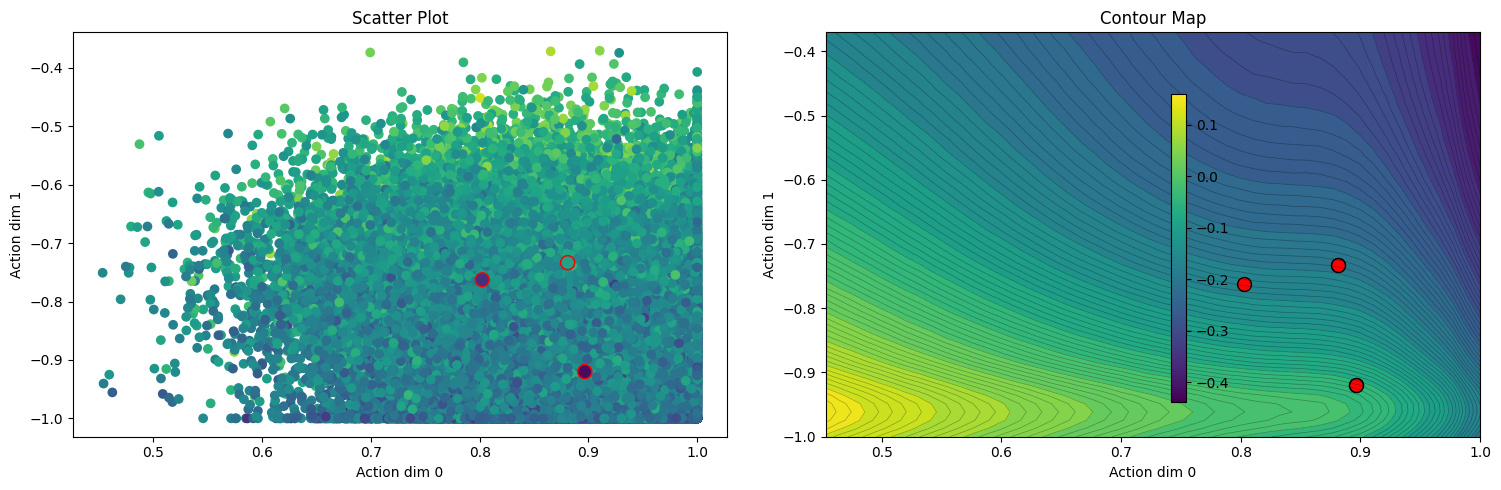

True vals: -82.77944946289062, -80.49736022949219, -80.97642517089844
Perturbed vals: -82.67167663574219, -79.94087982177734, -81.3593978881836


<Figure size 640x480 with 0 Axes>

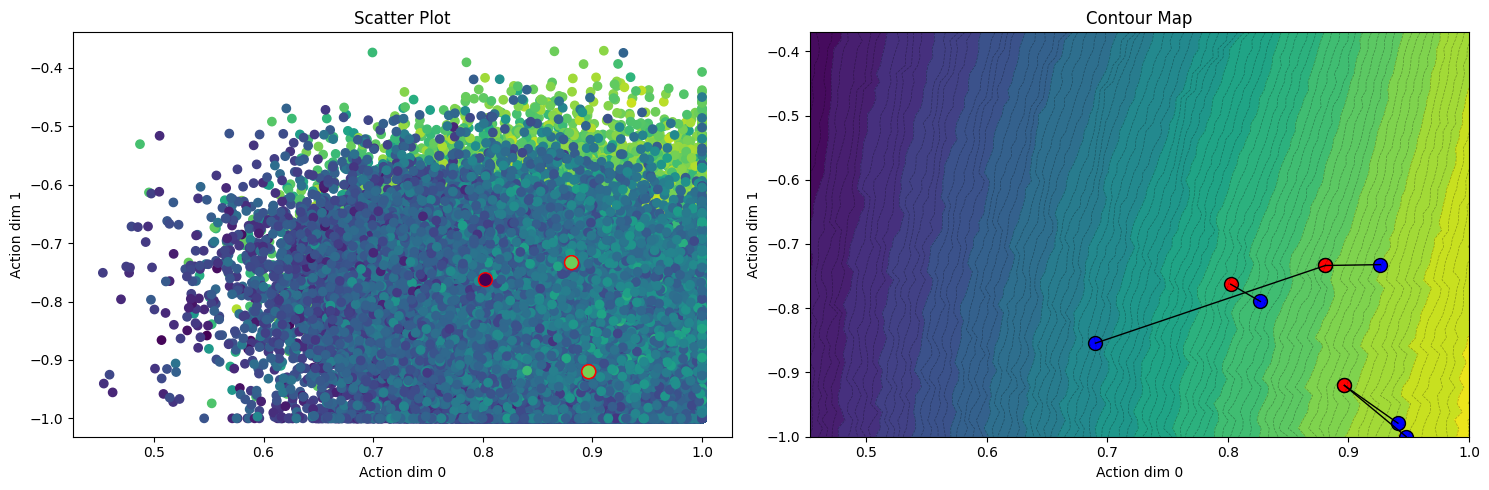

In [46]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# Make a perturbation over the target action
perturbation_scale = 0.1
num_actions = 10000
perturbed_actions_list = []
for action in similar_actions:
    perturbed_action = action + np.random.normal(0, perturbation_scale, (num_actions, action_dim))
    perturbed_action = np.clip(perturbed_action, -1, 1)
    perturbed_actions_list.append(perturbed_action)

perturbed_actions = np.concatenate(perturbed_actions_list, axis=0)

perturbed_lyapunov_values = lyapunov_value(params, apply_fn, target_state.reshape(1, -1).repeat(num_actions*similar_actions.shape[0], axis=0), perturbed_actions)

dim1, dim2 = 0,1

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: scatter plot
scatter = ax1.scatter(perturbed_actions[:, dim1], perturbed_actions[:, dim2], c=perturbed_lyapunov_values, cmap='viridis')
# color by value with red edge
true_vals = lyapunov_value(params, apply_fn, similar_states, similar_actions)
print(f"True vals: {true_vals.min()}, {true_vals.max()}, {true_vals.mean()}")
print(f"Perturbed vals: {perturbed_lyapunov_values.min()}, {perturbed_lyapunov_values.max()}, {perturbed_lyapunov_values.mean()}")
true_colors = plt.cm.viridis((true_vals - perturbed_lyapunov_values.min()) / (perturbed_lyapunov_values.max() - perturbed_lyapunov_values.min()))
ax1.scatter(similar_actions[:, dim1], similar_actions[:, dim2], c=true_colors, s=100, edgecolors='red')
ax1.set_xlabel(f'Action dim {dim1}')
ax1.set_ylabel(f'Action dim {dim2}')
ax1.set_title('Scatter Plot')

# Right plot: contour map
# Create a grid for contour plotting
x_min, x_max = perturbed_actions[:, dim1].min(), perturbed_actions[:, dim1].max()
y_min, y_max = perturbed_actions[:, dim2].min(), perturbed_actions[:, dim2].max()
x_grid = np.linspace(x_min, x_max, 50)
y_grid = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Create grid points for evaluation
grid_points = np.column_stack([X.ravel(), Y.ravel()])
# Pad with zeros for other action dimensions
full_grid_actions = np.zeros((grid_points.shape[0], action_dim))
full_grid_actions[:, dim1] = grid_points[:, 0]
full_grid_actions[:, dim2] = grid_points[:, 1]

# Evaluate lyapunov values on the grid
grid_lyapunov_values = lyapunov_value(params, apply_fn, target_state.reshape(1, -1).repeat(grid_points.shape[0], axis=0), full_grid_actions)
Z = grid_lyapunov_values.reshape(X.shape)

# Plot contour map
contour = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.contour(X, Y, Z, levels=100, colors='black', alpha=0.3, linewidths=0.5)
ax2.scatter(similar_actions[:, dim1], similar_actions[:, dim2], c='red', s=100, edgecolors='black')
ax2.set_xlabel(f'Action dim {dim1}')
ax2.set_ylabel(f'Action dim {dim2}')
ax2.set_title('Contour Map')

# Add colorbar
plt.colorbar(scatter, ax=[ax1, ax2], shrink=0.8)

plt.tight_layout()
plt.show()

# Plot SA values

plt.clf()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
perturbed_sa_values = compute_sa_values(critic_fn, target_state.reshape(1, -1).repeat(num_actions*similar_actions.shape[0], axis=0), perturbed_actions, batch_size=1000)

scatter = ax1.scatter(perturbed_actions[:, dim1], perturbed_actions[:, dim2], c=perturbed_sa_values, cmap='viridis')
# color by value with red edge
true_sa_values = compute_sa_values(critic_fn, similar_states, similar_actions, batch_size=1000)
print(f"True vals: {true_sa_values.min()}, {true_sa_values.max()}, {true_sa_values.mean()}")
print(f"Perturbed vals: {perturbed_sa_values.min()}, {perturbed_sa_values.max()}, {perturbed_sa_values.mean()}")
true_colors = plt.cm.viridis((true_sa_values - perturbed_sa_values.min()) / (perturbed_sa_values.max() - perturbed_sa_values.min()))
ax1.scatter(similar_actions[:, dim1], similar_actions[:, dim2], c=true_colors, s=100, edgecolors='red')
ax1.set_xlabel(f'Action dim {dim1}')
ax1.set_ylabel(f'Action dim {dim2}')
ax1.set_title('Scatter Plot')

# Create a grid for contour plotting
x_min, x_max = perturbed_actions[:, dim1].min(), perturbed_actions[:, dim1].max()
y_min, y_max = perturbed_actions[:, dim2].min(), perturbed_actions[:, dim2].max()
x_grid = np.linspace(x_min, x_max, 50)
y_grid = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x_grid, y_grid)

# Create grid points for evaluation
grid_points = np.column_stack([X.ravel(), Y.ravel()])
# Pad with zeros for other action dimensions
full_grid_actions = np.zeros((grid_points.shape[0], action_dim))
full_grid_actions[:, dim1] = grid_points[:, 0]
full_grid_actions[:, dim2] = grid_points[:, 1]

# Evaluate lyapunov values on the grid
grid_sa_values = compute_sa_values(critic_fn, target_state.reshape(1, -1).repeat(grid_points.shape[0], axis=0), full_grid_actions, batch_size=1000)
Z = grid_sa_values.reshape(X.shape)
ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.contour(X, Y, Z, levels=100, colors='black', alpha=0.3, linewidths=0.5)

# Draw the lines between the similar actions and the model predictions yielded from the same states (from xy to xy)
for i in range(similar_actions.shape[0]):
    ax2.plot([similar_actions[i, dim1], model_preds[i, dim1]], [similar_actions[i, dim2], model_preds[i, dim2]], c='black', linewidth=1)
ax2.scatter(similar_actions[:, dim1], similar_actions[:, dim2], c='red', s=100, edgecolors='black')
ax2.scatter(model_preds[:, dim1], model_preds[:, dim2], c='blue', s=100, edgecolors='black')
ax2.set_xlabel(f'Action dim {dim1}')
ax2.set_ylabel(f'Action dim {dim2}')
ax2.set_title('Contour Map')
plt.tight_layout()
plt.show()

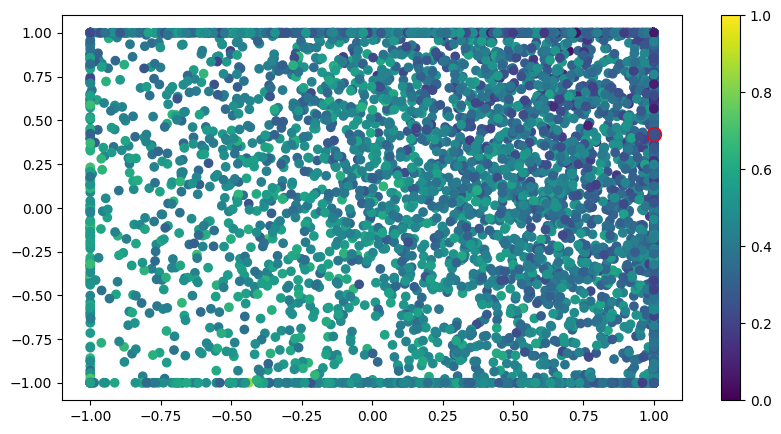

In [33]:
# Make a perturbation over the target action
perturbation_scale = 1
num_actions = 10000
perturbed_actions = target_action + np.random.normal(0, perturbation_scale, (num_actions, action_dim))
perturbed_actions = np.clip(perturbed_actions, -1, 1)

perturbed_lyapunov_values = lyapunov_value(params, apply_fn, target_state.reshape(1, -1).repeat(num_actions, axis=0), perturbed_actions)

dim1, dim2 = 2,3

plt.figure(figsize=(10, 5))
plt.scatter(perturbed_actions[:, dim1], perturbed_actions[:, dim2], c=perturbed_lyapunov_values, cmap='viridis')
# color by value with red edge
true_val = lyapunov_value(params, apply_fn, target_state, target_action)
true_color = plt.cm.viridis((true_val - perturbed_lyapunov_values.min()) / (perturbed_lyapunov_values.max() - perturbed_lyapunov_values.min()))
plt.scatter(target_action[dim1], target_action[dim2], c=true_color, s=100, edgecolors='red')
plt.colorbar()
plt.show()


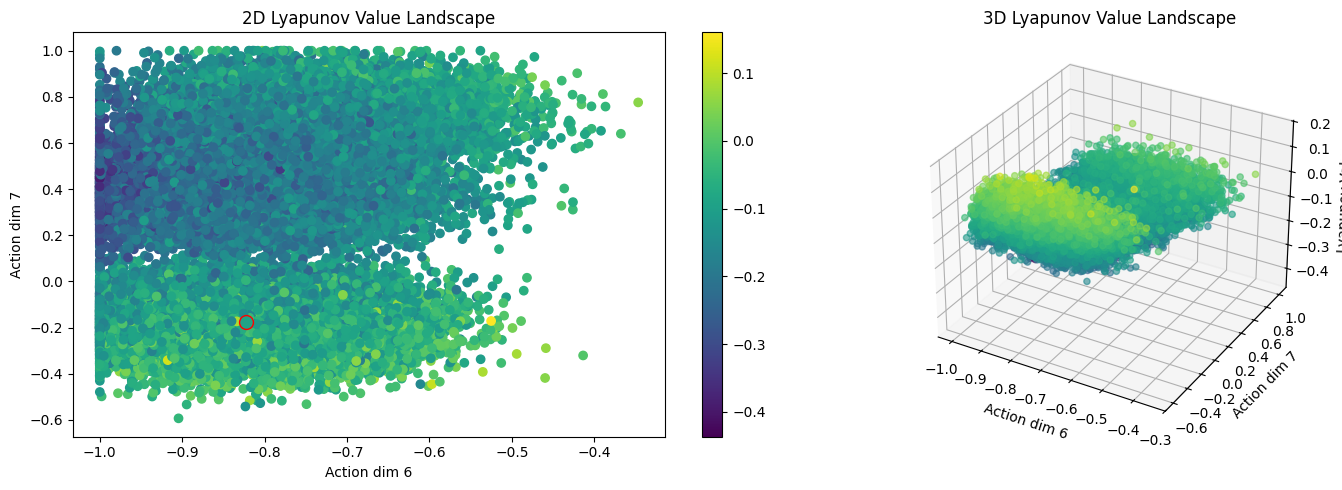

True action Lyapunov value: -0.0908
Mean of lowest 10% perturbed values: -0.3300
Mean of all perturbed values: -0.1481
Expert advantage (true < perturbed): 25.72%


In [47]:
# # Make a perturbation over the target action
# perturbation_scale = 1
# num_actions = 100000
# perturbed_actions = target_action + np.random.normal(0, perturbation_scale, (num_actions, action_dim))
# perturbed_actions = np.clip(perturbed_actions, -1, 1)

# perturbed_lyapunov_values = lyapunov_value(params, apply_fn, target_state.reshape(1, -1).repeat(num_actions, axis=0), perturbed_actions)

dim1, dim2 = 6,7

# Create 3D surface plot
fig = plt.figure(figsize=(15, 5))

# 2D scatter plot
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(perturbed_actions[:, dim1], perturbed_actions[:, dim2], c=perturbed_lyapunov_values, cmap='viridis')
# color by value with red edge
true_val = lyapunov_value(params, apply_fn, target_state, target_action)
true_color = plt.cm.viridis((true_val - perturbed_lyapunov_values.min()) / (perturbed_lyapunov_values.max() - perturbed_lyapunov_values.min()))
ax1.scatter(target_action[dim1], target_action[dim2], c=true_color, s=100, edgecolors='red')
ax1.set_xlabel(f'Action dim {dim1}')
ax1.set_ylabel(f'Action dim {dim2}')
ax1.set_title('2D Lyapunov Value Landscape')
plt.colorbar(scatter, ax=ax1)

# 3D surface plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(perturbed_actions[:, dim1], perturbed_actions[:, dim2], perturbed_lyapunov_values, 
           c=perturbed_lyapunov_values, cmap='viridis', alpha=0.6)
# Highlight the true action value in 3D
ax2.scatter(target_action[dim1], target_action[dim2], true_val, 
           c='red', s=200, edgecolors='black', linewidth=2, alpha=1.0)
ax2.set_xlabel(f'Action dim {dim1}')
ax2.set_ylabel(f'Action dim {dim2}')
ax2.set_zlabel('Lyapunov Value')
ax2.set_title('3D Lyapunov Value Landscape')

plt.tight_layout()
plt.show()

# Lower bound (or expectile) provides better barrier?

# Output the mean value of the lowest 10% of the values with true value
print(f"True action Lyapunov value: {true_val.item():.4f}")
print(f"Mean of lowest 10% perturbed values: {np.mean(np.sort(perturbed_lyapunov_values)[:int(0.1 * num_actions)]):.4f}")
print(f"Mean of all perturbed values: {np.mean(perturbed_lyapunov_values):.4f}")
print(f"Expert advantage (true < perturbed): {np.mean(true_val < perturbed_lyapunov_values):.2%}")


  0%|          | 0/50000 [00:00<?, ?it/s]/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.set_state to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.set_state` for environment variables or `env.get_wrapper_attr('set_state')` that will search the reminding wrappers.
  logger.warn(
100%|██████████| 50000/50000 [02:01<00:00, 410.13it/s]
/home/jaehyeok/miniconda3/envs/fql/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


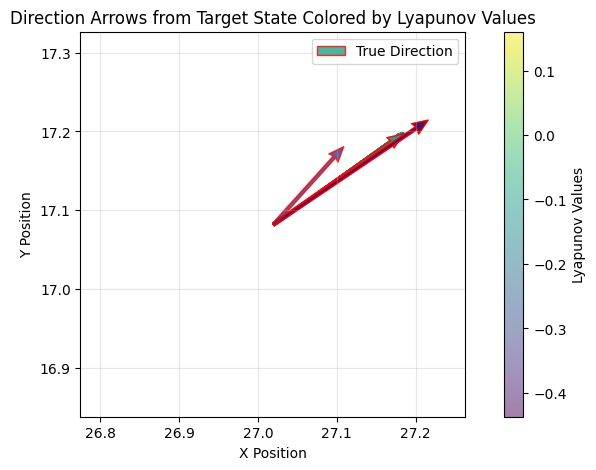

In [48]:
qpos_dim = 15
qvel_dim = 14

directions = []

for action in tqdm(perturbed_actions):
    env.reset()
    env.set_state(target_state[:qpos_dim], target_state[qpos_dim:qpos_dim+qvel_dim])
    next_ob, reward, terminated, truncated, info = env.step(action)

    directions.append(next_ob[:2] - target_state[:2])

directions = np.array(directions)

# Calculate the largest direction magnitude to set appropriate plot size
max_magnitude = np.max(np.linalg.norm(directions, axis=1))
plot_margin = max_magnitude * 0.2  # Add 20% margin

plt.figure(figsize=(10, 5))

# --- Use plt.quiver for efficient and correct plotting ---
# The origin position (curr_pos)
curr_pos = target_state[:2]

# The direction vectors (dx, dy) for the quiver plot
dx = directions[:, 0]
dy = directions[:, 1]

# Use plt.quiver with proper parameters
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    perturbed_lyapunov_values,  # Use Lyapunov values for color
    cmap='viridis',             # The colormap to use
    alpha=0.5,
    angles='xy',                # Ensure arrows point correctly
    scale_units='xy',
    scale=1
)

# plot true directions from similar_states and similar_actions
true_directions = []
true_lyapunov_vals = []

for i, (state, action) in enumerate(zip(similar_states, similar_actions)):
    env.reset()
    env.set_state(state[:qpos_dim], state[qpos_dim:qpos_dim+qvel_dim])
    next_ob, reward, terminated, truncated, info = env.step(action)
    true_direction = next_ob[:2] - state[:2]
    true_directions.append(true_direction)
    true_lyapunov_val = lyapunov_value(params, apply_fn, state, action)
    true_lyapunov_vals.append(true_lyapunov_val)

true_directions = np.array(true_directions)
true_lyapunov_vals = np.array(true_lyapunov_vals)

# Plot all true direction arrows
for i, (true_dir, true_val) in enumerate(zip(true_directions, true_lyapunov_vals)):
    true_color = plt.cm.viridis((true_val - perturbed_lyapunov_values.min()) / (perturbed_lyapunov_values.max() - perturbed_lyapunov_values.min()))
    plt.quiver(curr_pos[0], curr_pos[1],
               true_dir[0], true_dir[1],
               color=true_color, alpha=0.8, edgecolor='red', linewidth=1.0,
               angles='xy', scale_units='xy', scale=1,
               width=0.008, headwidth=4, headlength=5,
               label='True Direction' if i == 0 else "")

# Set plot limits based on the largest direction magnitude
plt.xlim(curr_pos[0] - max_magnitude - plot_margin, curr_pos[0] + max_magnitude + plot_margin)
plt.ylim(curr_pos[1] - max_magnitude - plot_margin, curr_pos[1] + max_magnitude + plot_margin)

# Add a colorbar to show the mapping of colors to Lyapunov values
cbar = plt.colorbar(quiver)
cbar.set_label('Lyapunov Values')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.title('Direction Arrows from Target State Colored by Lyapunov Values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

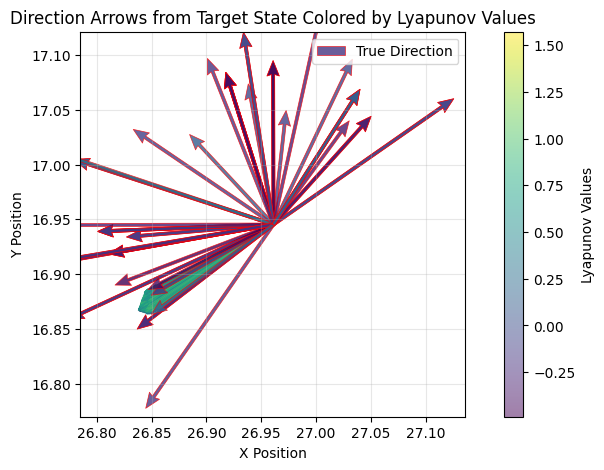

In [68]:
plt.figure(figsize=(10, 5))

# --- Use plt.quiver for efficient and correct plotting ---
# The origin position (curr_pos)
curr_pos = target_state[:2]

# The direction vectors (dx, dy) for the quiver plot
dx = directions[:, 0]
dy = directions[:, 1]

# Use plt.quiver with proper parameters
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    perturbed_lyapunov_values,  # Use Lyapunov values for color
    cmap='viridis',             # The colormap to use
    alpha=0.5,
    angles='xy',                # Ensure arrows point correctly
    scale_units='xy',
    scale=1
)

# Plot all true direction arrows
for i, (true_dir, true_val) in enumerate(zip(true_directions, true_lyapunov_vals)):
    true_color = plt.cm.viridis((true_val - perturbed_lyapunov_values.min()) / (perturbed_lyapunov_values.max() - perturbed_lyapunov_values.min()))
    plt.quiver(curr_pos[0], curr_pos[1],
               true_dir[0], true_dir[1],
               color=true_color, alpha=0.8, edgecolor='red', linewidth=0.5,
               angles='xy', scale_units='xy', scale=1,
               width=0.008, headwidth=4, headlength=5,
               label='True Direction' if i == 0 else "")

# Set plot limits based on the largest direction magnitude
plt.xlim(curr_pos[0] - max_magnitude - plot_margin, curr_pos[0] + max_magnitude + plot_margin)
plt.ylim(curr_pos[1] - max_magnitude - plot_margin, curr_pos[1] + max_magnitude + plot_margin)

# Add a colorbar to show the mapping of colors to Lyapunov values
cbar = plt.colorbar(quiver)
cbar.set_label('Lyapunov Values')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.title('Direction Arrows from Target State Colored by Lyapunov Values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

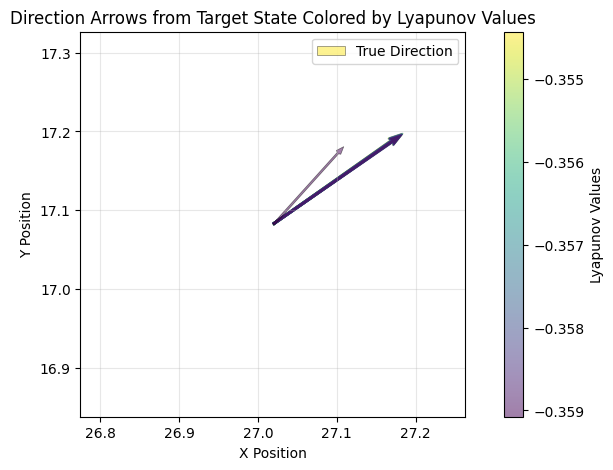

In [49]:
# plot the true direction and the perturbed directions with the lowest 10% of the value that is lower than the true value
plt.figure(figsize=(10, 5))

underestimated_perturbed_values = perturbed_lyapunov_values < true_val

per_vals = perturbed_lyapunov_values[underestimated_perturbed_values]

tau = 0.2
low_perturbed_lyapunov_values_idx = np.argsort(per_vals)[::-1][:int(tau * per_vals.shape[0])]
low_perturbed_lyapunov_values = per_vals[low_perturbed_lyapunov_values_idx]
low_directions = directions[low_perturbed_lyapunov_values_idx]

# --- Use plt.quiver for efficient and correct plotting ---
# The origin position (curr_pos)
curr_pos = target_state[:2]

# The direction vectors (dx, dy) for the quiver plot
dx = low_directions[:, 0]
dy = low_directions[:, 1]

# Use plt.quiver with proper parameters
quiver = plt.quiver(
    [curr_pos[0]] * len(dx),  # Repeat origin x for each arrow
    [curr_pos[1]] * len(dy),  # Repeat origin y for each arrow
    dx,
    dy,
    low_perturbed_lyapunov_values,  # Use Lyapunov values for color
    cmap='viridis',             # The colormap to use
    alpha=0.5,
    angles='xy',                # Ensure arrows point correctly
    scale_units='xy',
    scale=1
)

true_color = plt.cm.viridis((true_val - low_perturbed_lyapunov_values.min()) / (low_perturbed_lyapunov_values.max() - low_perturbed_lyapunov_values.min()))
plt.quiver(curr_pos[0], curr_pos[1],
           true_direction[0], true_direction[1],
           true_val,
           color=true_color, alpha=0.5, edgecolor='black', linewidth=0.5,
           angles='xy', scale_units='xy', scale=1,
           width=0.005, headwidth=3, headlength=4,
           label='True Direction')

# Set plot limits based on the largest direction magnitude
plt.xlim(curr_pos[0] - max_magnitude - plot_margin, curr_pos[0] + max_magnitude + plot_margin)
plt.ylim(curr_pos[1] - max_magnitude - plot_margin, curr_pos[1] + max_magnitude + plot_margin)

# Add a colorbar to show the mapping of colors to Lyapunov values
cbar = plt.colorbar(quiver)
cbar.set_label('Lyapunov Values')

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.title('Direction Arrows from Target State Colored by Lyapunov Values')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()